# Quickstart — Mamdani inference

Build the credit-risk premium system, evaluate it, and visualize it.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import fuzzytool as fz
from fuzzytool import datasets, viz

## A ready-made system

`datasets.credit_risk()` returns a configured `Mamdani` plus its variables.

In [2]:
sys, score, dti, premium = datasets.credit_risk()
for s, d in [(800, 10), (660, 30), (520, 42)]:
    print(f'score={s}, dti={d}% -> premium = {sys(score=s, dti=d):.2f} pts')

score=800, dti=10% -> premium = 1.91 pts
score=660, dti=30% -> premium = 6.00 pts
score=520, dti=42% -> premium = 10.16 pts


## Membership functions

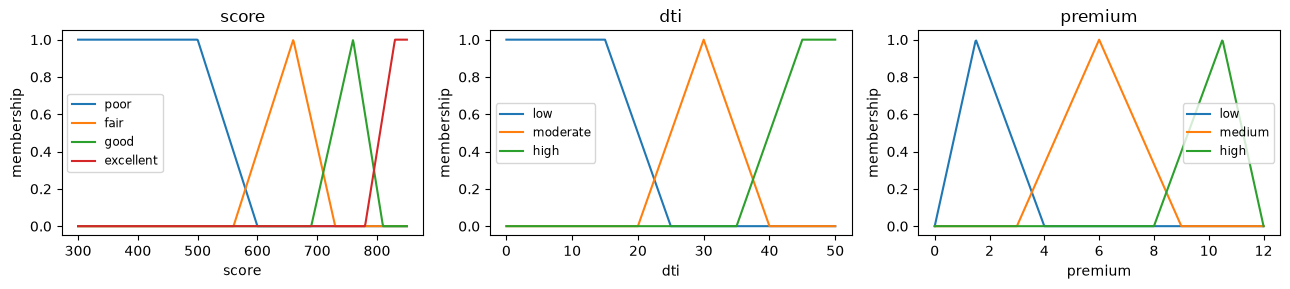

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, v in zip(axes, (score, dti, premium)):
    viz.plot_variable(v, ax=ax)
plt.tight_layout(); plt.show()

## Control surface

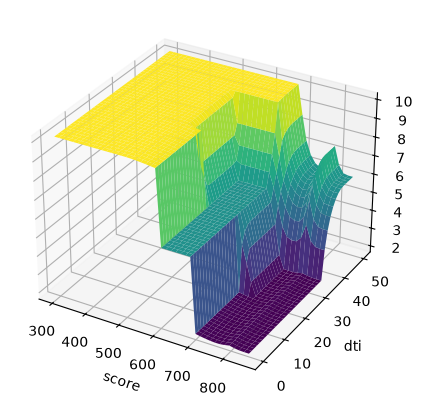

In [4]:
viz.control_surface(sys, score, dti); plt.show()

## Building one from scratch

Rules read like logic: `|` is OR, `&` is AND, `~` is NOT.

In [5]:
q = fz.Variable('quality', (0, 10), terms=['poor', 'ok', 'great'])
out = fz.Variable('out', (0, 100), terms=['low', 'mid', 'high'])
m = fz.Mamdani()
m.rule(q['poor'], out['low'])
m.rule(q['ok'], out['mid'])
m.rule(q['great'], out['high'])
print(m(quality=7.5))

55.95245714285714
